# Actividad: Volatility Skew — SPY

**Objetivo:** Calcular la volatilidad implícita para al menos 10 strikes distintos del vencimiento `2026-04-17` en el rango `[S0 × 0.88, S0 × 1.10]`, construir una tabla de resultados y graficar el *volatility skew*.

**Activo:** SPY  
**Vencimiento:** 2026-04-17  
**Tipo de opción:** Call  
**Tasa libre de riesgo:** 4.2% (tasa aproximada del Treasury a corto plazo)

In [1]:
# ─────────────────────────────────────────────
# CELDA 1: Importaciones y funciones base
# Se reutilizan las funciones del código visto en clase:
#   - bs_price: precio teórico de Black-Scholes
#   - bs_vega:  derivada del precio respecto a sigma (usada en Newton)
#   - implied_vol: encuentra IV combinando Brent + Newton
# ─────────────────────────────────────────────

import numpy as np
import pandas as pd
import yfinance as yf
from datetime import date
from scipy.stats import norm
from scipy.optimize import brentq, newton
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


# ── Black-Scholes: precio teórico ──────────────────────────────────────────
def bs_price(S, K, r, T, sigma, option="call"):
    """Devuelve el precio Black-Scholes de una call o put europea."""
    if sigma <= 0 or T <= 0:
        if option == "call":
            return max(0.0, S - K * np.exp(-r * T))
        else:
            return max(0.0, K * np.exp(-r * T) - S)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option.lower() == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


# ── Black-Scholes: vega (derivada respecto a sigma) ────────────────────────
def bs_vega(S, K, r, T, sigma):
    """Calcula la vega de la opción. Se usa como derivada en el método de Newton."""
    if sigma <= 0 or T <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)


# ── Volatilidad implícita: Brent con fallback a Newton ─────────────────────
def implied_vol(price_mkt, S, K, r, T, option="call",
                brent_bounds=(1e-6, 5.0), tol=1e-8, maxiter=100, seed=0.2):
    """
    Calcula la volatilidad implícita dada una prima de mercado.
    Estrategia:
      1. Verifica que el precio esté dentro de los límites teóricos de no arbitraje.
      2. Intenta el método de Brent (robusto, no requiere derivada).
      3. Si Brent falla, usa Newton-Raphson con vega como derivada.
    """
    # Límites teóricos (no arbitraje)
    if option == "call":
        lower = max(0.0, S - K * np.exp(-r * T))
        upper = S
    else:
        lower = max(0.0, K * np.exp(-r * T) - S)
        upper = K * np.exp(-r * T)

    if not (lower - 1e-12 <= price_mkt <= upper + 1e-12):
        raise ValueError(f"Precio fuera de rango teórico [{lower:.4f}, {upper:.4f}]")

    # Función objetivo: BS(sigma) - precio_mercado = 0
    def f(sig):
        return bs_price(S, K, r, T, sig, option) - price_mkt

    a, b = brent_bounds
    fa, fb = f(a), f(b)

    # Expande el extremo superior si la función no cambia de signo
    if fa * fb > 0:
        for b_try in [10.0, 15.0, 25.0, 50.0]:
            fb = f(b_try)
            if fa * fb <= 0:
                b = b_try
                break

    # Intento 1: método de Brent
    try:
        iv = brentq(f, a, b, xtol=tol, maxiter=maxiter)
        return iv
    except Exception:
        pass

    # Intento 2: Newton-Raphson con vega como derivada
    try:
        iv = newton(lambda s: f(s), seed,
                    fprime=lambda s: bs_vega(S, K, r, T, s),
                    tol=tol, maxiter=maxiter)
        if iv > 0:
            return iv
    except Exception:
        pass

    raise RuntimeError("No se pudo encontrar la volatilidad implícita.")


print("✓ Funciones cargadas correctamente.")

✓ Funciones cargadas correctamente.


In [2]:
# ─────────────────────────────────────────────
# CELDA 2: Parámetros del mercado
# Se obtienen dinámicamente: S0 (precio spot) y
# la cadena de opciones para el vencimiento elegido.
# ─────────────────────────────────────────────

# Parámetros fijos
TICKER = 'SPY'
EXP    = '2026-04-17'    # Vencimiento fijado en la actividad
r      = 0.042           # Tasa libre de riesgo (Treasury corto plazo ~4.2%)
today  = date.today()

# ── Precio spot S0 (dinámico, último cierre disponible) ───────────────────
tk   = yf.Ticker(TICKER)
data = yf.download(TICKER, start='2023-01-01', end=today, progress=False)['Close']
S0   = float(data.iloc[-1])

# ── Tiempo al vencimiento en años ─────────────────────────────────────────
T = (date.fromisoformat(EXP) - today).days / 365

print(f"Activo   : {TICKER}")
print(f"S0       : {S0:.2f}")
print(f"Exp      : {EXP}")
print(f"T (años) : {T:.4f}  ({round(T*365)} días)")
print(f"r        : {r:.1%}")

Activo   : SPY
S0       : 670.79
Exp      : 2026-04-17
T (años) : 0.0822  (30 días)
r        : 4.2%


In [3]:
# ─────────────────────────────────────────────
# CELDA 3: Selección de strikes y cálculo de IV
#
# Pasos:
#  1. Descarga la cadena de calls para el vencimiento.
#  2. Filtra los strikes dentro del rango [S0×0.88, S0×1.10].
#  3. Para cada strike disponible con liquidez mínima,
#     calcula el precio mid = (bid + ask) / 2.
#  4. Calcula la IV con implied_vol().
#  5. Construye un DataFrame con los resultados.
# ─────────────────────────────────────────────

# Límites del rango de strikes pedido en la actividad
K_min = S0 * 0.88
K_max = S0 * 1.10

# Descarga la cadena de calls
calls = tk.option_chain(EXP).calls.copy()

# Filtra por rango y liquidez mínima
calls = calls[
    (calls['strike'] >= K_min) &
    (calls['strike'] <= K_max) &
    (calls['bid'] > 0) &
    (calls['ask'] > 0)
].copy()

# Calcula precio mid dinámicamente
calls['mid'] = (calls['bid'] + calls['ask']) / 2

# ── Bucle de cálculo de IV ─────────────────────────────────────────────────
records = []

for _, row in calls.iterrows():
    K   = row['strike']
    mid = row['mid']
    try:
        iv = implied_vol(mid, S0, K, r, T, option="call")
        # Descarta IVs fuera de rango razonable
        if 0.01 <= iv <= 2.0:
            records.append({
                'Strike': K,
                'Bid'   : round(row['bid'], 4),
                'Ask'   : round(row['ask'], 4),
                'Mid'   : round(mid, 4),
                'IV (%)'  : round(iv * 100, 2)
            })
    except Exception:
        pass  # Strike sin solución (precio fuera de límites teóricos)

df_skew = pd.DataFrame(records).reset_index(drop=True)

print(f"Strikes calculados: {len(df_skew)}")
print(f"Rango de strikes  : [{df_skew['Strike'].min():.1f}, {df_skew['Strike'].max():.1f}]")

Strikes calculados: 88
Rango de strikes  : [650.0, 737.0]


In [4]:
# ─────────────────────────────────────────────
# CELDA 4: Tabla de resultados
#
# Muestra la tabla con columnas:
# Strike | Bid | Ask | Mid | IV (%)
# ─────────────────────────────────────────────

print(f"\n{'='*52}")
print(f"  Volatility Skew — {TICKER}  |  Vencimiento: {EXP}")
print(f"  S0 = {S0:.2f}  |  r = {r:.1%}  |  T = {T:.4f} años")
print(f"{'='*52}\n")

# Configuración de display para que se vea completo en Colab
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', 50)

display(df_skew.style
        .format({'Strike': '{:.1f}', 'Bid': '{:.4f}',
                 'Ask': '{:.4f}', 'Mid': '{:.4f}', 'IV (%)': '{:.2f}'})
        .highlight_min(subset=['IV (%)'], color='#d4edda')   # verde = IV más baja
        .highlight_max(subset=['IV (%)'], color='#f8d7da')   # rojo  = IV más alta
        .set_caption(f"Tabla 1. Volatilidad implícita por strike — Calls {TICKER} ({EXP})"))


  Volatility Skew — SPY  |  Vencimiento: 2026-04-17
  S0 = 670.79  |  r = 4.2%  |  T = 0.0822 años



,Strike,Bid,Ask,Mid,IV (%)
0,650.0,23.0500,23.2800,23.1650,6.42
1,651.0,21.1100,23.9200,22.5150,7.97
2,652.0,20.4500,23.2100,21.8300,8.72
3,653.0,20.7100,21.2600,20.9850,8.84
4,654.0,19.4100,21.4600,20.4350,9.61
5,655.0,19.6400,19.8600,19.7500,9.94
6,656.0,18.9200,20.1300,19.5250,11.07
7,657.0,17.4300,19.5300,18.4800,10.59
8,658.0,17.7100,17.7700,17.7400,10.64
9,659.0,17.0700,17.1300,17.1000,10.84


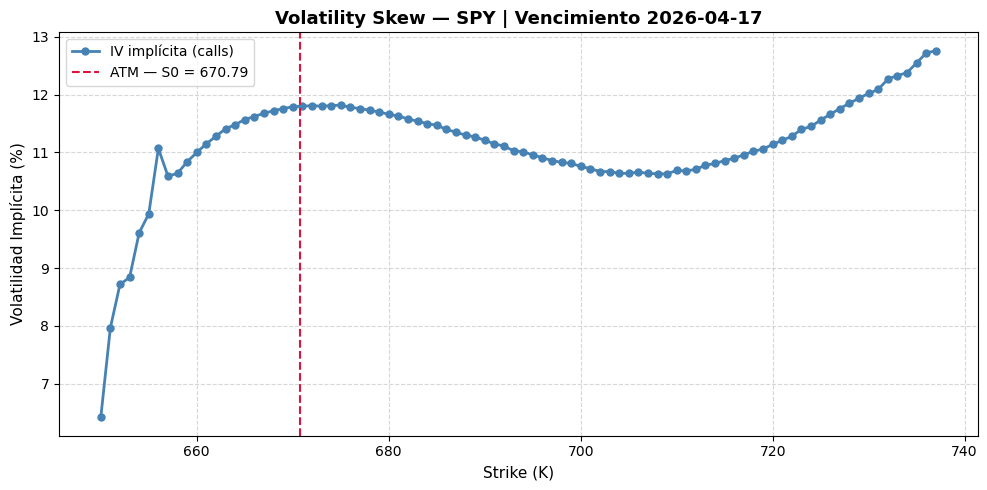

In [5]:
# ─────────────────────────────────────────────
# CELDA 5: Gráfica del Volatility Skew
#
# Grafica IV (%) vs Strike.
# Una línea vertical en S0 indica el precio ATM.
# ─────────────────────────────────────────────

strikes = df_skew['Strike'].values
ivs     = df_skew['IV (%)'].values

fig, ax = plt.subplots(figsize=(10, 5))

# Curva principal del skew
ax.plot(strikes, ivs, marker='o', linewidth=2,
        color='steelblue', markersize=5, label='IV implícita (calls)')

# Línea vertical en S0 (precio ATM)
ax.axvline(x=S0, color='crimson', linestyle='--', linewidth=1.5,
           label=f'ATM — S0 = {S0:.2f}')

# Etiquetas y formato
ax.set_title(f'Volatility Skew — {TICKER} | Vencimiento {EXP}', fontsize=13, fontweight='bold')
ax.set_xlabel('Strike (K)', fontsize=11)
ax.set_ylabel('Volatilidad Implícita (%)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Observaciones

*(Completa esta sección después de correr el notebook y ver los resultados)*

**1. ¿Qué forma tiene la curva?**  
_Describe si la curva es plana, tiene forma de sonrisa (smile), o es asimétrica hacia un lado (skew)._

**2. ¿Dónde está la IV más alta y la más baja?**  
_Identifica en qué zona de la curva (OTM, ATM, ITM) aparecen los extremos._

**3. ¿Qué implica ese patrón sobre las expectativas del mercado?**  
_Relaciona la forma del skew con la percepción de riesgo de los participantes del mercado._

**4. ¿Por qué Black-Scholes no puede generar este patrón por sí solo?**  
_Recuerda el supuesto de volatilidad constante del modelo._